HR-аналитики компании «Работа с заботой» хотят избежать финансовых потерь и оттока сотрудников. Для этого применяется машинное обучение, чтобы быстрее и точнее отвечать на вопросы бизнеса.
<br>
В ходе проекта требуется решить две задачи:
<br>
<br>
<li><b>построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.</b>
<br>
Данные: тренировочная выборка - train_job_satisfaction_rate.csv, входные признаки тестовой выборки - test_features.csv, целевой признак тестовой выборки - test_target_job_satisfaction_rate.csv.
job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.</li>
<li><b>построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.</b>
<br>
Данные: тренировочная выборка - train_quit.csv, входные признаки тестовой выборки - test_features.csv, целевой признак тестовой выборки - test_target_quit.csv. Целевой признак: quit — увольнение сотрудника из компании.</li>
<br>

In [85]:
!pip install phik -q

In [86]:
import pandas as pd
import numpy as np
import phik
import seaborn as sns

from matplotlib import pyplot as plt
from scipy import stats
from scipy.stats import norm, randint, uniform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder, 
    StandardScaler, 
    MinMaxScaler, 
    RobustScaler, 
    OrdinalEncoder
)
from sklearn.datasets import make_classification
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    precision_recall_curve, 
    accuracy_score, 
    precision_score, 
    r2_score, 
    recall_score, 
    roc_auc_score,
    f1_score
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer
from sklearn.linear_model import Lasso 
from sklearn.ensemble import RandomForestRegressor

In [87]:
# Случайное состояние и размер тестовой выборки
RANDOM_STATE = 42
TEST_SIZE = 0.25

## Предсказание уровня удовлетворённости сотрудника 

### Загрузка данных

In [88]:
df_train_job_sat_rate = pd.read_csv('/Users/test/Desktop/Яндекс Практикум/Проекты/HR/train_job_satisfaction_rate.csv')

In [89]:
df_test_features = pd.read_csv('/Users/test/Desktop/Яндекс Практикум/Проекты/HR/test_features.csv')

In [90]:
df_test_target_job_sat_rate= pd.read_csv('/Users/test/Desktop/Яндекс Практикум/Проекты/HR/test_target_job_satisfaction_rate.csv')

In [91]:
df_test_features = df_test_features.replace(' ', np.nan)

In [92]:
df_test_features = df_test_features.replace('sinior', 'senior')

In [93]:
 datasets = [
        ('df_train_job_sat_rate', 'Таблица df_train_job_sat_rate'),
        ('df_test_features', 'Таблица df_test_features'),
        ('df_test_target_job_sat_rate', 'df_test_target_job_sat_rate')
    ]

for dataset_name, label in datasets:
    df = globals()[dataset_name]
    print(label + ':')
    display(df.head())
    df.info()
    print('-' * 70)

Таблица df_train_job_sat_rate:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB
----------------------------------------------------------------------
Таблица df_test_features:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1997 non-null   object
 2   level                  1999 non-null   object
 3   workload               1999 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB
----------------------------------------------------------------------
df_test_target_job_sat_rate:


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB
----------------------------------------------------------------------


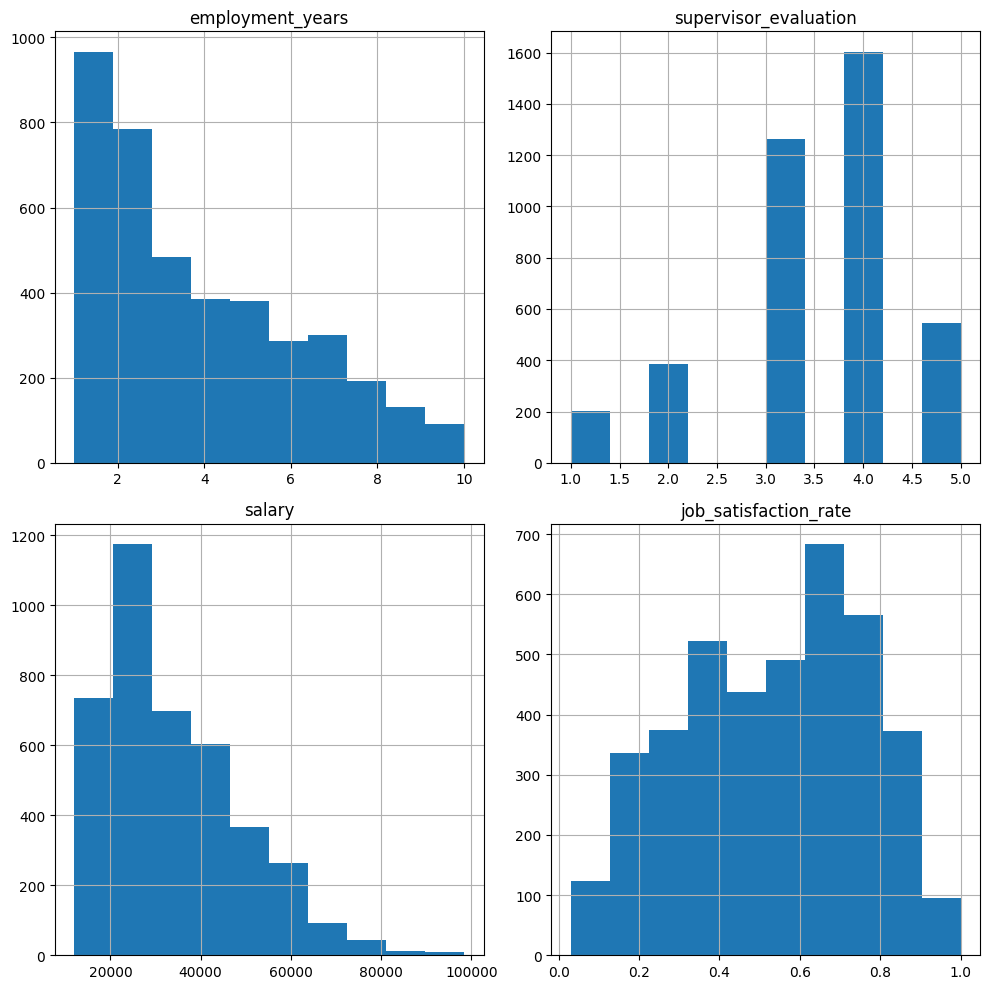

In [94]:
df_train_job_sat_rate_hist = df_train_job_sat_rate.drop('id', axis=1)
df_train_job_sat_rate_hist.hist(figsize=(10, 10))
plt.tight_layout()
plt.show() 

In [95]:
display(df_train_job_sat_rate)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20
...,...,...,...,...,...,...,...,...,...,...
3995,457950,technology,junior,high,2,no,no,3,46800,0.45
3996,957499,sales,junior,medium,2,no,no,4,21600,0.68
3997,533318,sales,middle,low,7,no,no,5,24000,0.76
3998,706868,sales,junior,medium,2,no,no,3,24000,0.48


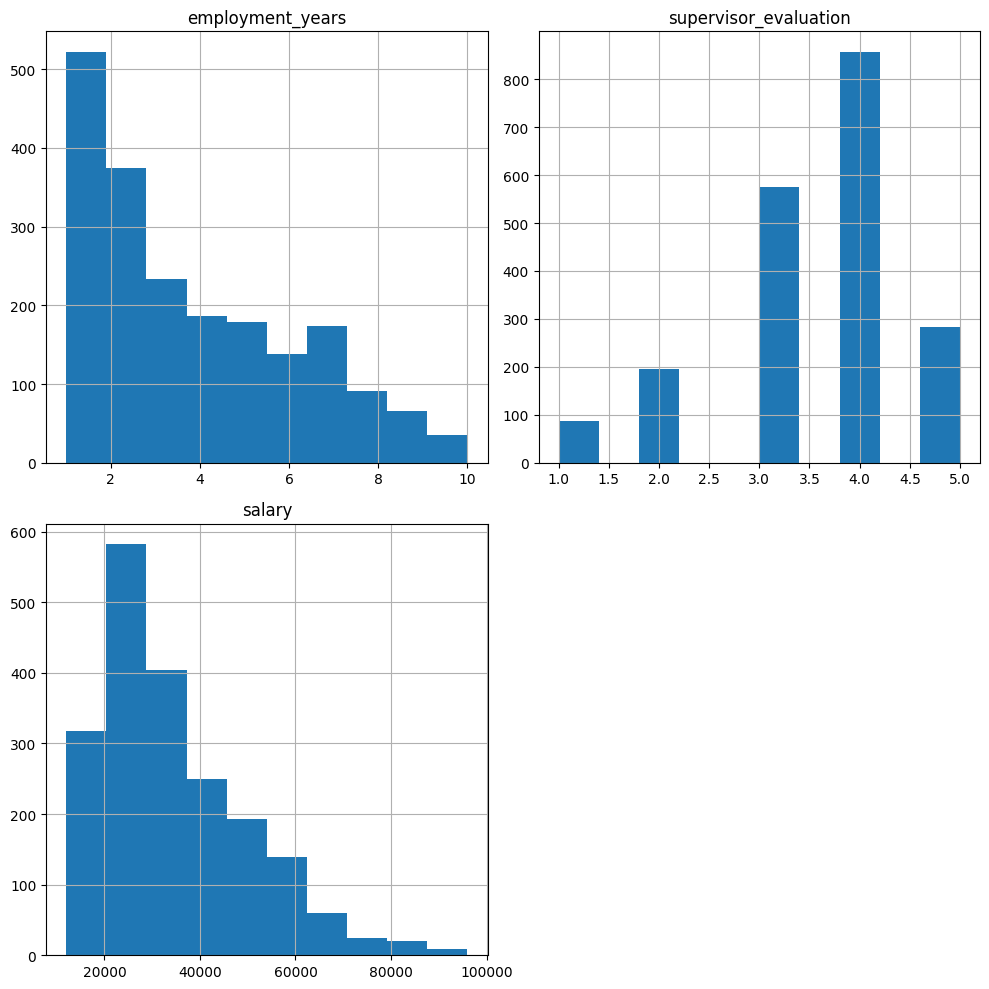

In [96]:
df_test_features
df_test_features_hist = df_test_features.drop('id', axis=1)
df_test_features_hist.hist(figsize=(10, 10))
plt.tight_layout()
plt.show()

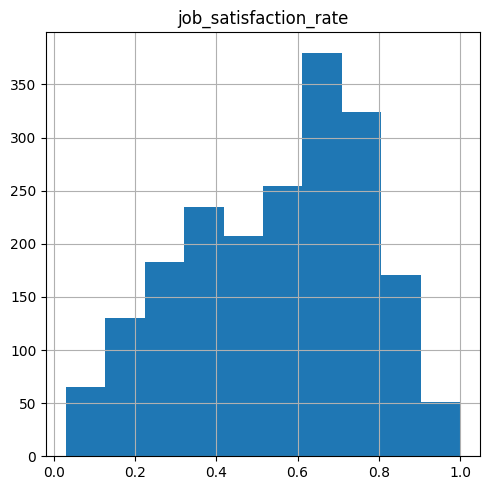

In [97]:
df_test_target_job_sat_rate_hist = df_test_target_job_sat_rate.drop('id', axis=1)
df_test_target_job_sat_rate_hist.hist(figsize=(5, 5))
plt.tight_layout()
plt.show() 

Данные во всех таблицах консистентные. Пропуски в таблицах df_train_job_sat_rate и df_test_target_job_sat_rate, тип данных везде корректный. Наименования столбцов и признаков корректные.

Данные можно использовать для дальнейшего исследования.

### Предобработка данных

In [98]:
df_train_job_sat_rate_dub = df_train_job_sat_rate.duplicated().sum()
print('Количество дубликатов:', df_train_job_sat_rate_dub)

Количество дубликатов: 0


In [99]:
df_test_features_dub = df_test_features.duplicated().sum()
print('Количество дубликатов:', df_test_features_dub)

Количество дубликатов: 0


In [100]:
def find_unique_object_values(dataframe):
    """
    Возвращает словарь с уникальными значениями для каждого столбца типа 'object'.
    """
    result = {}
    for column in dataframe.columns:
        if dataframe[column].dtype == 'object':
            result[column] = set(dataframe[column])
            
    return result
print('Таблица df_train_job_sat_rate:', find_unique_object_values(df_train_job_sat_rate))
print('Таблица df_test_features:', find_unique_object_values(df_test_features))

Таблица df_train_job_sat_rate: {'dept': {nan, 'marketing', 'technology', 'purchasing', 'sales', 'hr'}, 'level': {nan, 'junior', 'middle', 'sinior'}, 'workload': {'medium', 'high', 'low'}, 'last_year_promo': {'yes', 'no'}, 'last_year_violations': {'yes', 'no'}}
Таблица df_test_features: {'dept': {nan, 'marketing', 'technology', 'purchasing', 'sales', 'hr'}, 'level': {nan, 'junior', 'middle', 'senior'}, 'workload': {'medium', nan, 'low', 'high'}, 'last_year_promo': {'yes', 'no'}, 'last_year_violations': {'yes', 'no'}}


In [101]:
df_train_job_sat_rate['level'] = (df_train_job_sat_rate['level'].replace('sinior', 'senior', regex=True))
df_test_features['level'] = (df_test_features['level'].replace('sinior', 'senior', regex=True))
df_test_features = df_test_features.replace(' ', np.nan)

In [102]:
# исходный порядок столбцов
original_columns = df_train_job_sat_rate.columns.tolist()

# столбцы для обработки
cols_to_process = ['dept', 'level']

# Задание препроцессора
data_preprocessor = ColumnTransformer([
    ('imputer', SimpleImputer(strategy='most_frequent'), cols_to_process)
], remainder='passthrough')

# Пайплайн
pipe_final = Pipeline(steps=[
    ('preprocessor', data_preprocessor)
])


df_train_job_sat_rate_processed = pipe_final.fit_transform(df_train_job_sat_rate)

# DataFrame с правильным порядком столбцов
df_train_job_sat_rate_processed = pd.DataFrame(
    df_train_job_sat_rate_processed,
    columns=cols_to_process + [col for col in original_columns if col not in cols_to_process],
    index=df_train_job_sat_rate.index
)

# восстановление точного порядка столбцов
df_train_job_sat_rate_processed = df_train_job_sat_rate_processed[original_columns]

# вбновление основного DataFrame
df_train_job_sat_rate.update(df_train_job_sat_rate_processed)

/var/folders/ym/f5fjw0nx4w784vncx5m0z3tw0000gn/T/ipykernel_1364/216338492.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.58 0.76 0.11 ... 0.76 0.48 0.18]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_train_job_sat_rate.update(df_train_job_sat_rate_processed)


In [103]:
df_train_job_sat_rate.info()
display(df_train_job_sat_rate)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   job_satisfaction_rate  4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.2
...,...,...,...,...,...,...,...,...,...,...
3995,457950,technology,junior,high,2,no,no,3,46800,0.45
3996,957499,sales,junior,medium,2,no,no,4,21600,0.68
3997,533318,sales,middle,low,7,no,no,5,24000,0.76
3998,706868,sales,junior,medium,2,no,no,3,24000,0.48


In [104]:
# исходный порядок столбцов
original_columns = df_test_features.columns.tolist()

# столбцы для обработки
cols_to_process = ['dept', 'level', 'workload']

# Задание препроцессора
data_preprocessor = ColumnTransformer([
    ('imputer', SimpleImputer(strategy='most_frequent'), cols_to_process)
], remainder='passthrough')

# Пайплайн
pipe_final = Pipeline(steps=[
    ('preprocessor', data_preprocessor)
])


df_test_features_processed = pipe_final.fit_transform(df_test_features)

# DataFrame с правильным порядком столбцов
df_test_features_processed = pd.DataFrame(
    df_test_features_processed,
    columns=cols_to_process + [col for col in original_columns if col not in cols_to_process],
    index=df_test_features.index
)

# восстановление точного порядка столбцов
df_test_features_processed = df_test_features_processed[original_columns]

# вбновление основного DataFrame
df_test_features.update(df_test_features_processed)

In [105]:
df_test_features.info()
display(df_test_features)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   2000 non-null   object
 2   level                  2000 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800
...,...,...,...,...,...,...,...,...,...
1995,393147,marketing,junior,low,3,no,no,3,20400
1996,109582,technology,middle,low,3,no,no,2,21600
1997,305653,technology,junior,low,1,no,no,3,14400
1998,160233,technology,middle,low,8,no,no,1,32400


In [106]:
df_train_job_sat_rate[['salary', 
                      'employment_years']] = df_train_job_sat_rate[['salary', 
                                                                  'employment_years']].astype('int')

df_train_job_sat_rate['job_satisfaction_rate'] = df_train_job_sat_rate['job_satisfaction_rate'].astype('float')

df_train_job_sat_rate[['supervisor_evaluation', 
                       'workload', 
                       'level']] = df_train_job_sat_rate[['supervisor_evaluation', 
                                                          'workload', 
                                                          'level']].astype('category')

In [107]:
df_test_features[['salary', 'employment_years']] = df_test_features[['salary', 'employment_years']].astype('int')
df_test_features[['supervisor_evaluation', 
                  'workload', 
                  'level']]= df_test_features[['supervisor_evaluation', 
                                               'workload', 
                                               'level']].astype('category')

In [108]:
df_train_job_sat_rate.info()
df_test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   id                     4000 non-null   int64   
 1   dept                   4000 non-null   object  
 2   level                  4000 non-null   category
 3   workload               4000 non-null   category
 4   employment_years       4000 non-null   int64   
 5   last_year_promo        4000 non-null   object  
 6   last_year_violations   4000 non-null   object  
 7   supervisor_evaluation  4000 non-null   category
 8   salary                 4000 non-null   int64   
 9   job_satisfaction_rate  4000 non-null   float64 
dtypes: category(3), float64(1), int64(3), object(3)
memory usage: 231.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------          

Обработаны пропуски в колонках 'dept', 'level' в двух датасетах путем заполнения наиболее частыми значениями, результаты сохранены в других датасетах df_test_features_processed и df_train_job_sat_rate_processed, которые будут использоваться в исследовательском анализе. В обогощенных датасетах восстановлены корректны типы данных.

### Исследовательский анализ

In [109]:
def discrete_plot(df, columns_list):
    """
    Функция строит гистограмму/счётчик для заданного дискретного признака в dataframe.
    
    :param df: Исходный dataset (DataFrame).
    :param column_name: Название столбца с дискретными значениями.
    """
   
    for col in columns_list:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col, color="#4C72B0", edgecolor="black", linewidth=1.5)
        plt.title(f'Распределение по "{col}"', fontsize=18)
        plt.xlabel(col, fontsize=14)
        plt.ylabel('Количество записей', fontsize=14)
        plt.show()

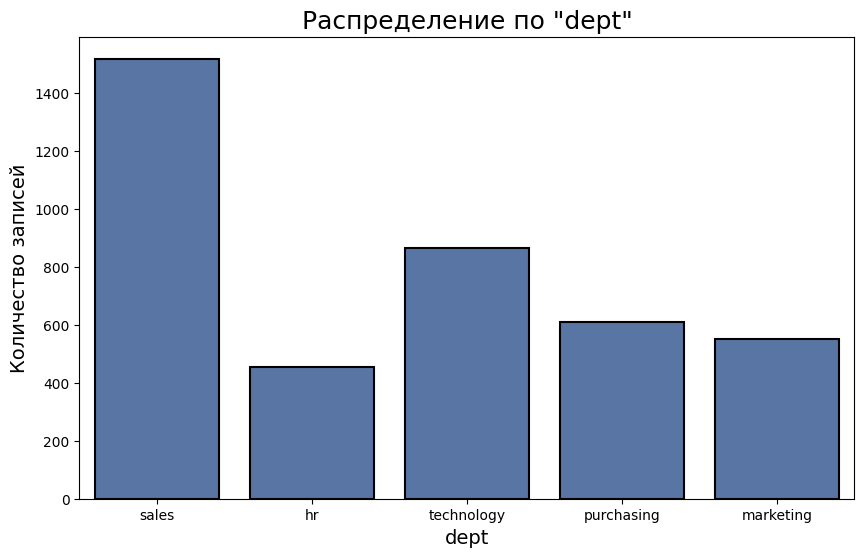

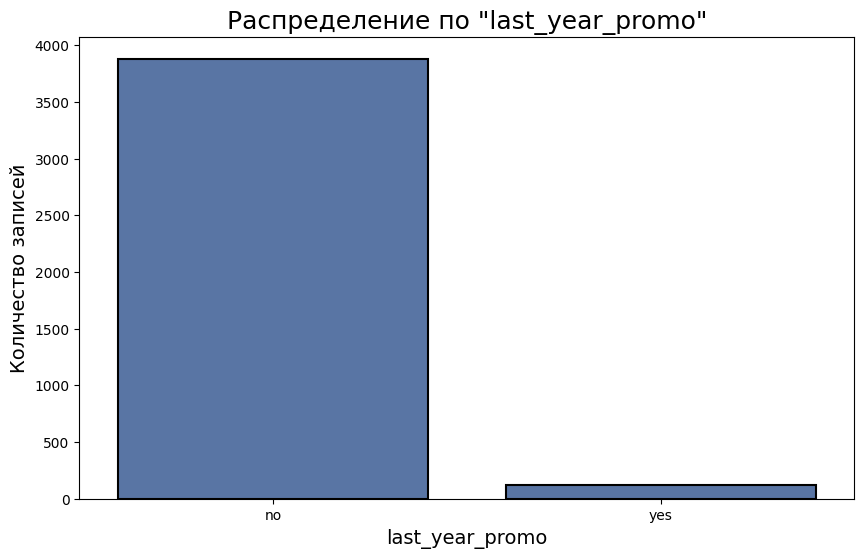

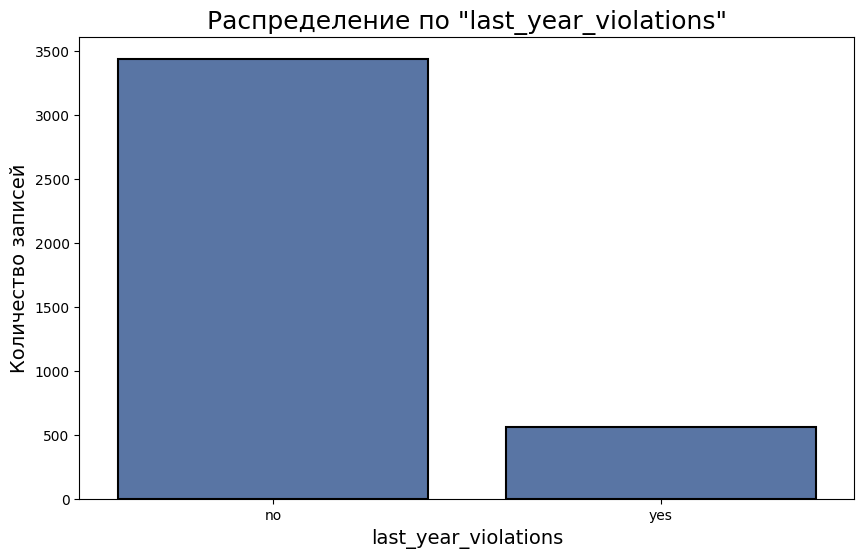

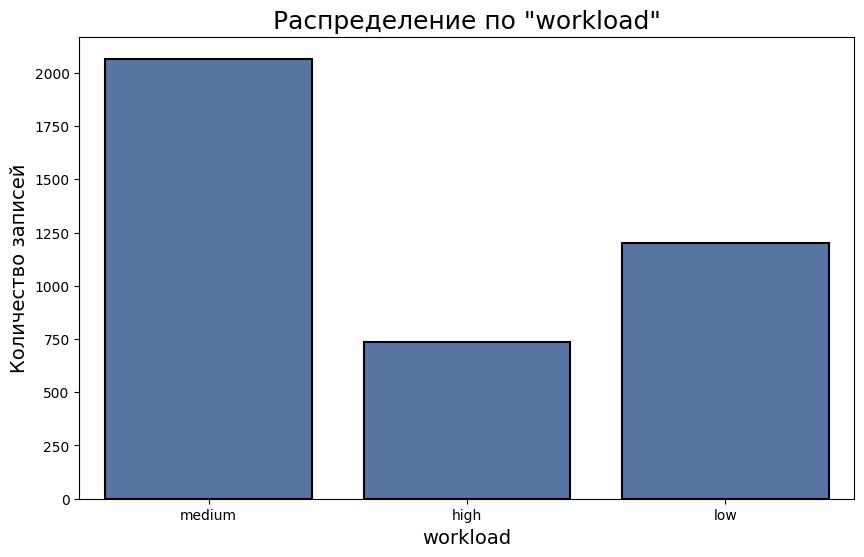

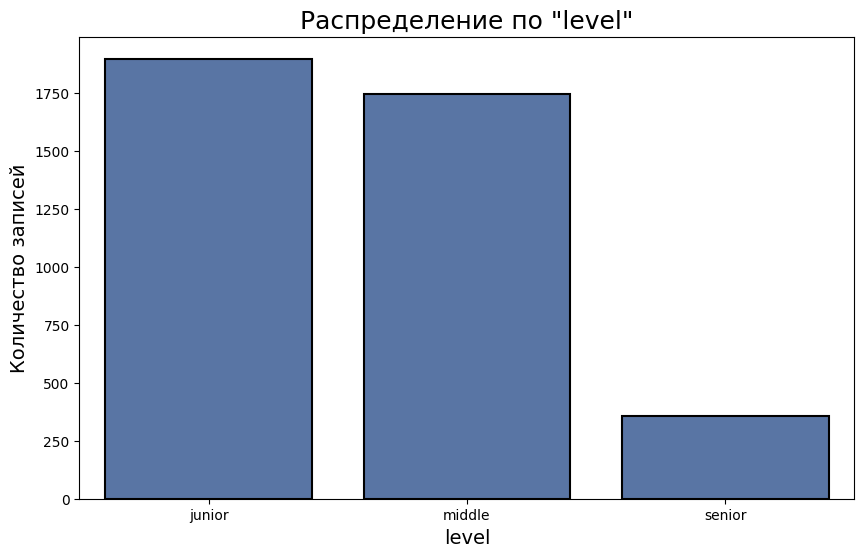

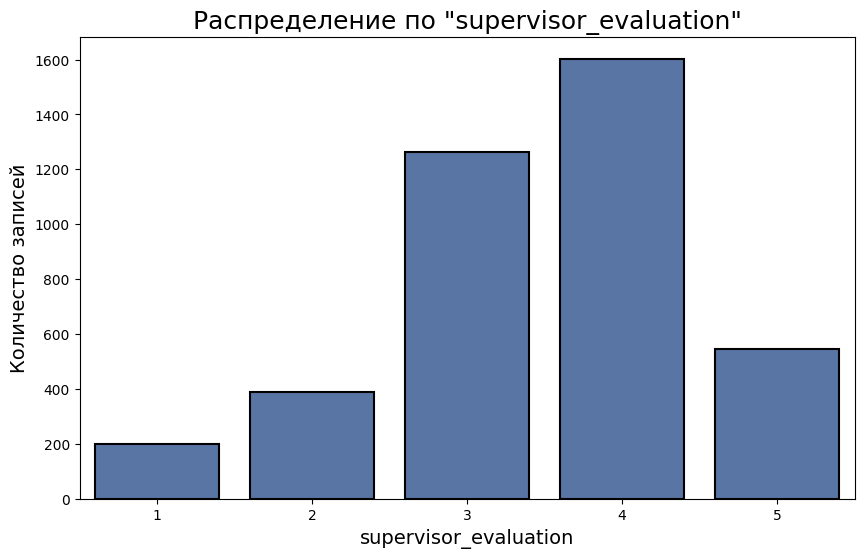

In [110]:
discrete_column = ['dept', 
                   'last_year_promo', 
                   'last_year_violations', 
                   'workload', 'level', 
                   'supervisor_evaluation']
discrete_plot(df_train_job_sat_rate_processed, discrete_column)

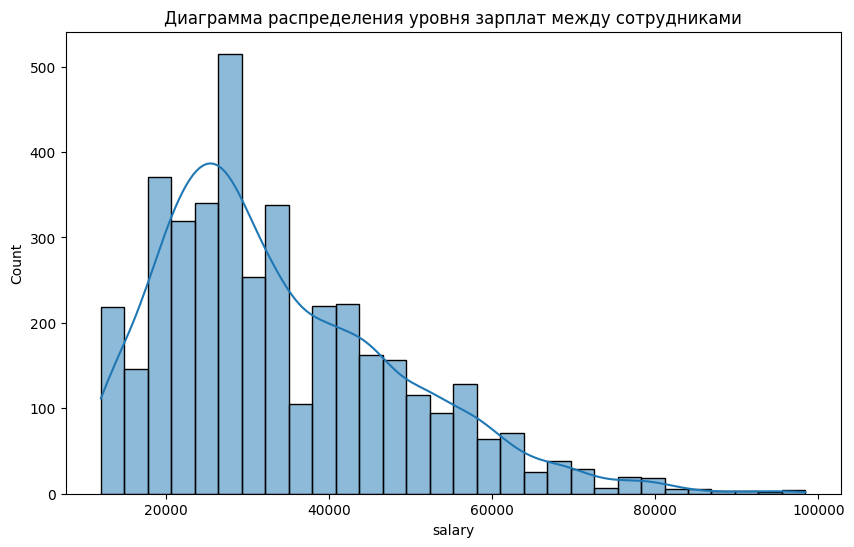

In [111]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_train_job_sat_rate, x='salary', bins=30, kde=True)
plt.title('Диаграмма распределения уровня зарплат между сотрудниками')
plt.show()

In [112]:
print(df_train_job_sat_rate['salary'].describe())

count     4000.000000
mean     33926.700000
std      14900.703838
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      98400.000000
Name: salary, dtype: float64


In [113]:
Q1 = df_train_job_sat_rate['salary'].quantile(0.25)
Q3 = df_train_job_sat_rate['salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_train_job_sat_rate = df_train_job_sat_rate[(df_train_job_sat_rate['salary'] >= lower_bound) & (df_train_job_sat_rate['salary'] <= upper_bound)]

In [114]:
print(df_test_features['salary'].describe())

count     2000.000000
mean     34066.800000
std      15398.436729
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64


In [115]:
Q1 = df_test_features['salary'].quantile(0.25)
Q3 = df_test_features['salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

ferma_main = df_test_features[(df_test_features['salary'] >= lower_bound) & (df_test_features['salary'] <= upper_bound)]

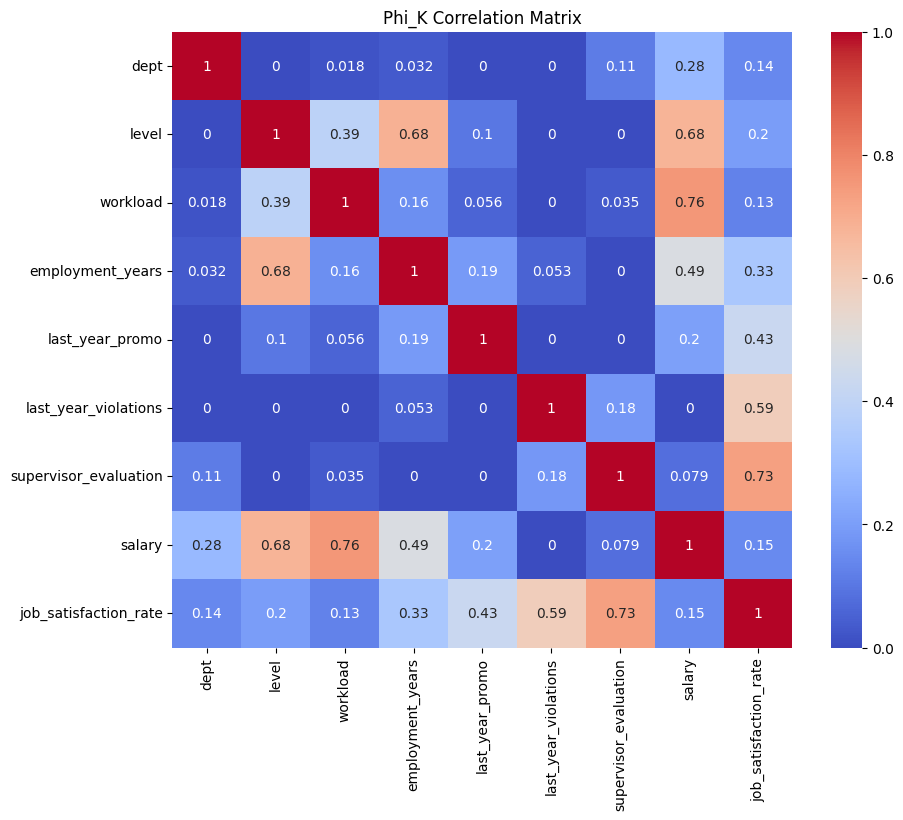

In [116]:
cols_to_drop = [
    'id'
]
df_corr = df_train_job_sat_rate.drop(columns=cols_to_drop, errors='ignore')

numerical_data = [
    'salary'
]

missing = [c for c in numerical_data if c not in df_corr.columns]
if missing:
    raise KeyError(f"Отсутствуют колонки: {missing}")

corr_matrix = df_corr.phik_matrix(numerical_data)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Phi_K Correlation Matrix')
plt.show()

▌ Анализ матрицы корреляции

- Высокая положительная корреляция наблюдается между признаками:
  - level и employment_years: 𝜌=0.684
  - workload и salary: 𝜌=0.755
  - supervisor_evaluation и job_satisfaction_rate: 𝜌=0.734

Эти связи указывают на высокую вероятность наличия мультиколлинеарности среди указанных пар признаков.



Оставлена одна переменная из каждой пары высоко-коррелированных признаков. Таким образом, выбраны признаки:

- dept
- level
- workload
- last_year_promo
- last_year_violations
- supervisor_evaluation

Этот набор обеспечивает минимальное количество зависимых признаков и снижает риски появления проблем с интерпретацией модели.


### Подготовка данных

In [117]:
ohe_columns = ['dept']
ord_columns = ['level', 'workload', 'last_year_promo', 'last_year_violations']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

ordinal_categories = {
    'level': ['junior', 'middle', 'senior'],
    'workload': ['low', 'medium', 'high'],
    'last_year_promo': ['no', 'yes'],
    'last_year_violations': ['no', 'yes']}

RANDOM_STATE = 42

ohe_pipe = Pipeline([
    ('simpleImputer', SimpleImputer(missing_values=np.nan, strategy = 'most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False, drop = 'first'))])

ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy = 'most_frequent')),
    ('ord', OrdinalEncoder(categories=[ordinal_categories[col] for col in ord_columns], 
        handle_unknown = 'use_encoded_value',
        unknown_value=np.nan)),
    ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy = 'most_frequent'))])

num_pipe = Pipeline([
    ('simpleImputer_le', SimpleImputer(missing_values=np.nan, strategy = 'median')),
    ('scaler', StandardScaler())])

data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_columns),
    ('ord', ord_pipe, ord_columns),
    ('num', num_pipe, num_columns)],
    remainder = 'passthrough')

pipe_rf = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))])


### Построение модели

In [ ]:
# Загрузка исходных данных
df_full = df_train_job_sat_rate.copy()  

hr_test = df_test_features.merge(df_test_target_job_sat_rate, on = 'id', how = 'outer')
hr_test_no_id = hr_test.drop(columns = ['id'])
df_train_job_sat_rate_no_id = df_train_job_sat_rate.drop(columns = ['id'])
X_train = train_job_sr_no_id.drop(columns = ['job_satisfaction_rate'], axis = 1)
y_train = train_job_sr_no_id['job_satisfaction_rate']

X_test = hr_test.drop(columns = ['id', 'job_satisfaction_rate'])
y_test = hr_test['job_satisfaction_rate']



print("Размеры выборок:", X_train.shape, X_test.shape)


def smape(y_true, y_pred):
    """
    Вычисление Symmetric Mean Absolute Percentage Error (SMAPE).
    """
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return 100 * np.sum(numerator / denominator) / len(y_true)

# Регистрация нашей собственной метрики для использования в GridSearch
smape_scorer = make_scorer(smape, greater_is_better=False)

# Создание общего пайплайна
pipe_final = Pipeline(steps=[
    ('preprocessor', data_preprocessor),
    ('regressor', None)  # Здесь позже определится лучшая модель
])

# Определение пространства поиска гиперпараметров
param_distributions = [
    {
        "regressor": [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'regressor__max_depth': [10, 15, 20, None],
        'regressor__min_samples_leaf': [6, 8, 10],
        'regressor__min_samples_split': [4, 6, 8]
    },
    {
        "regressor": [Lasso(random_state=RANDOM_STATE)],
        "regressor__alpha": [0.01, 0.1, 1, 10, 100]
    },
    {
        "regressor": [RandomForestRegressor(random_state=RANDOM_STATE)],
        "regressor__n_estimators": [50, 100, 200],
        'regressor__max_depth': [10, 15, 20, None],
        'regressor__min_samples_leaf': [1, 2, 5],
        'regressor__max_features': ['sqrt', 'log2']
    }
]

# Объект для рандомизированного поиска наилучших гиперпараметров
randomized_search = RandomizedSearchCV(
    estimator=pipe_final,
    param_distributions=param_distributions,
    cv=5,
    random_state=RANDOM_STATE,
    scoring=smape_scorer,
    n_iter=10,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)


# Обучение моделей
randomized_search.fit(X_train, y_train)

# Лучшие найденные параметры и модель
best_model = randomized_search.best_estimator_

print("\nЛучшая модель и её параметры:\n", best_model)
print("\nЗначение метрики SMAPE на кросс-валидации:",round( -randomized_search.best_score_, 2))

Размеры выборок: (3940, 8) (2000, 8)


ValueError: Invalid parameter 'regressor' for estimator Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
       

In [122]:
X_test = df_test_features.drop('id', axis=1)
y_pred = best_model.predict(X_test)
y_true = df_test_target_job_sat_rate.iloc[:, 1].values
smape_value = smape(y_true, y_pred)

print('SMAPE на тестовой выборке:', round(smape_value, 3))

SMAPE на тестовой выборке: 48.385


In [120]:
display(X_train.shape)
display(y_train.head())

(3940, 8)

0    0.58
1    0.76
2    0.11
3    0.37
4    0.20
Name: job_satisfaction_rate, dtype: float64